In [17]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import ast
import torch
import pickle
import numpy as np


## Training curves

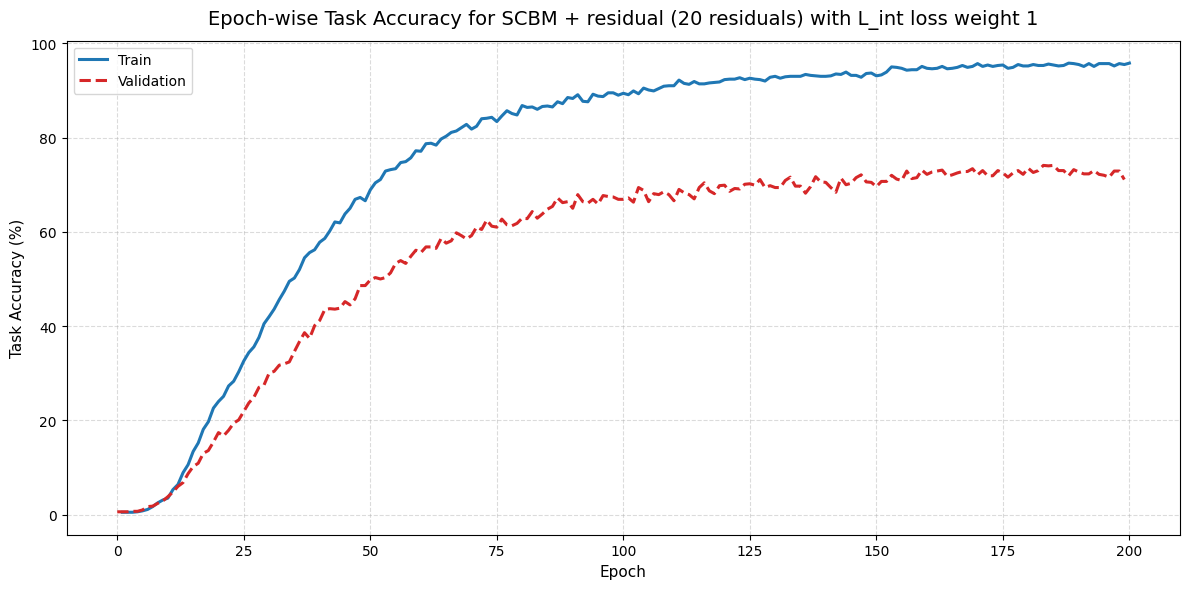

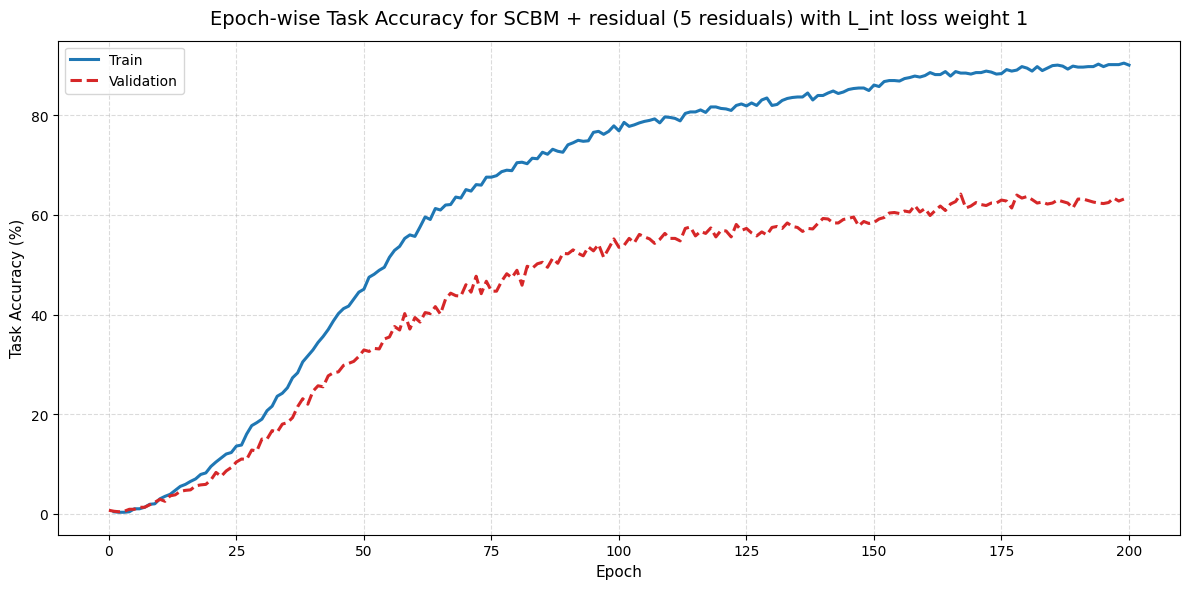

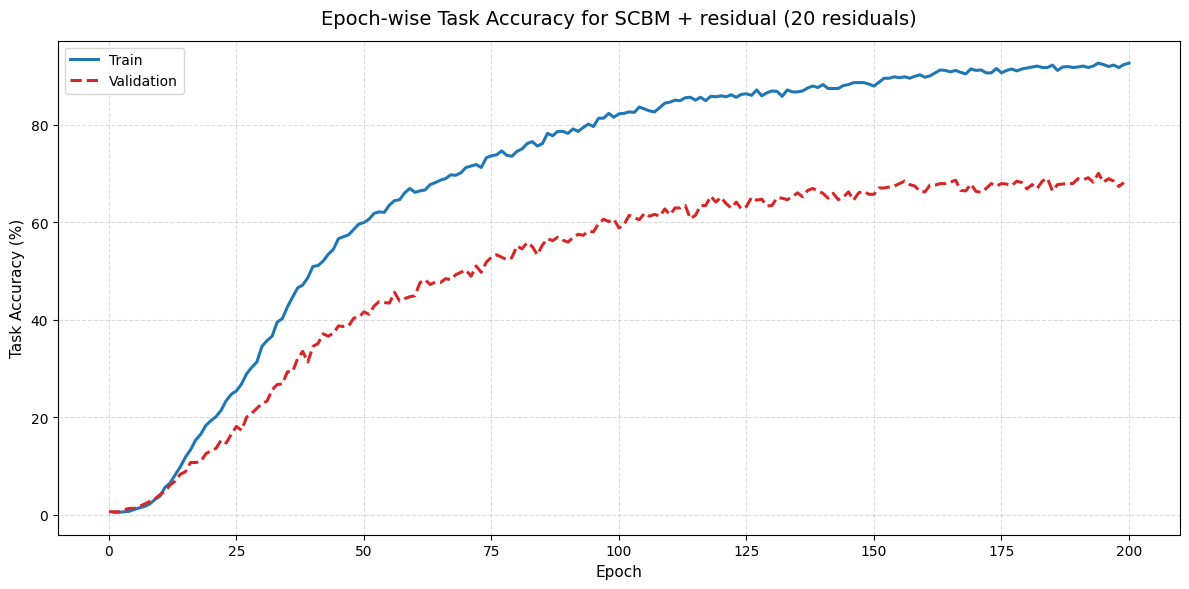

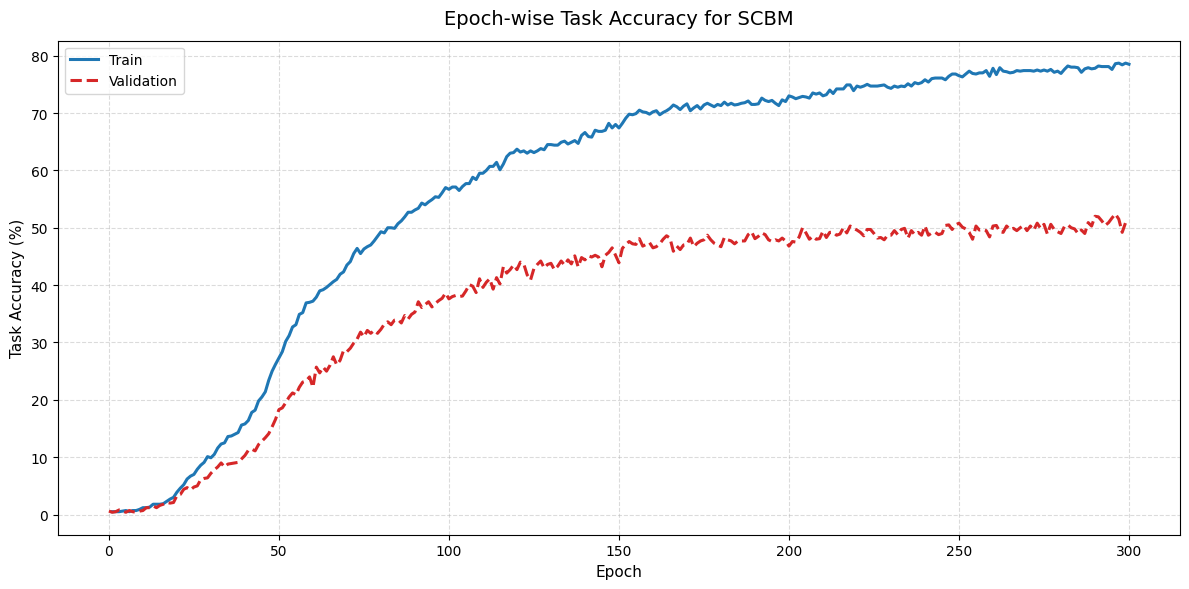

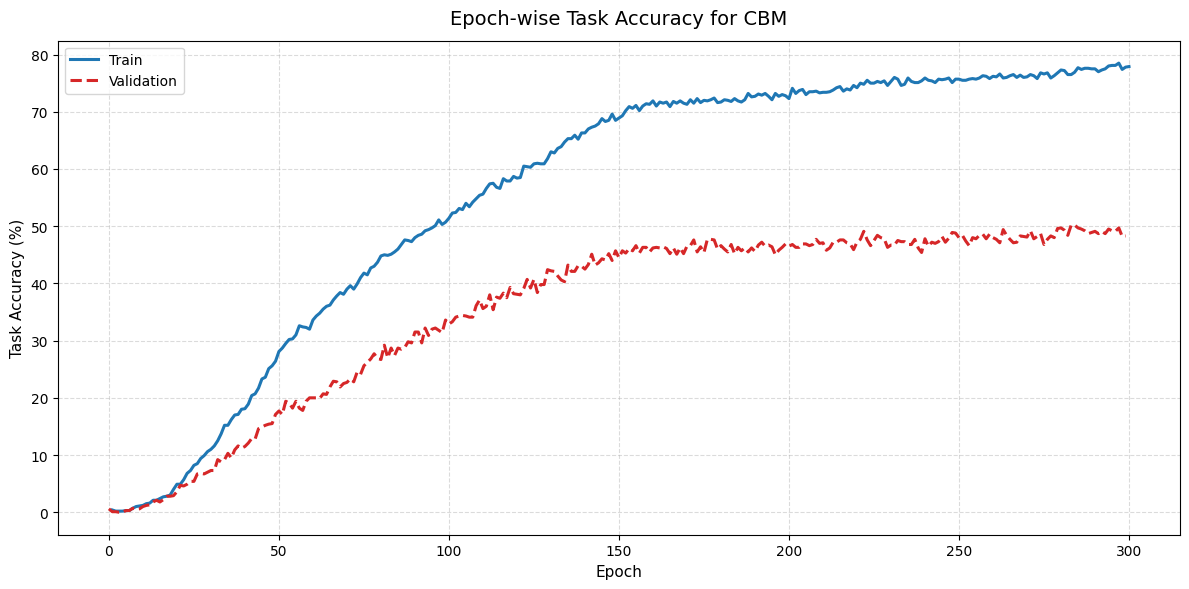

In [18]:
def extract_epoch_accuracies(full_model_path, split="Train"):
    epoch_accuracies = []
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Epoch" in line and "y_accuracy" in line and "c_accuracy" in line and split in line:
                epoch_num = re.findall(r"Epoch\s*(\d+)", line)[0]
                y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", line)[0]
                c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", line)[0]
                epoch_accuracies.append((int(epoch_num), float(y_accuracy) * 100, float(c_accuracy) * 100))
    return epoch_accuracies

scbm_model_dir = os.path.join("experiments", "scbm", "TravelingBirds")
scbm_res_model_dir = os.path.join("experiments", "scbm_residual", "TravelingBirds")
cbm_model_dir = os.path.join("experiments", "cbm", "TravelingBirds")

model_dirs_titles = [(scbm_res_model_dir,
                      "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed",
                      "SCBM + residual (20 residuals) with L_int loss weight 1"),
                    (scbm_res_model_dir, 
                      "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", 
                      "SCBM + residual (5 residuals) with L_int loss weight 1"),
                     (scbm_res_model_dir,
                      "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e",
                      "SCBM + residual (20 residuals)"),
                     (scbm_model_dir,
                      "Mateo_025_2026-08-10_17-06-22_5b4d7",
                      "SCBM"),
                     (cbm_model_dir,
                      "Mateo_025_2026-08-10_17-07-25_84e08",
                      "CBM")]


for root_model_dir, model_name, title in model_dirs_titles:
    full_model_path = os.path.join(root_model_dir, model_name)
    train_accuracies = extract_epoch_accuracies(full_model_path, split="Train")
    val_accuracies = extract_epoch_accuracies(full_model_path, split="Validation")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        [epoch[0] for epoch in train_accuracies],
        [epoch[1] for epoch in train_accuracies],
        label="Train",
        color="#1f77b4",
        linewidth=2.2,
        markersize=6,
    )
    ax.plot(
        [epoch[0] for epoch in val_accuracies],
        [epoch[1] for epoch in val_accuracies],
        label="Validation",
        color="#d62728",
        linestyle="--",
        linewidth=2.2,
        markersize=6,
    )
    ax.set_title(f"Epoch-wise Task Accuracy for {title}", fontsize=14, pad=12)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Task Accuracy (%)", fontsize=11)
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()
    


## Interventions 

In [19]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="TravelingBirds", return_c_auroc=False, return_auroc=False, intervention_on_val=False, folder=None):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []
    if intervention_on_val and folder is not None:
        raise ValueError("If intervention_on_val is True, folder should be None. The function will automatically look for the validation log.")
    elif intervention_on_val:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log_val.txt")
    elif folder is not None:
        log_txt_path = os.path.join(experiment_path, model_dir, folder, "intervention_log.txt")
    else:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log.txt")
    with open(log_txt_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

In [20]:
def retrieve_acc_from_log(model_dir, linear_model=False):

                with open(os.path.join(model_dir, "log.txt"), "r") as f:
                    lines = f.readlines()
                    test_line = lines[-1]
                    if linear_model:
                        y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = None
                        c_auc = None
                    else:
                        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
                    y_accuracy = float(y_accuracy) * 100
                    if c_accuracy is not None:
                        c_accuracy = float(c_accuracy) * 100
                    return y_accuracy, c_accuracy, c_auc

### OOD incomplete travellingBirds dataset interventions

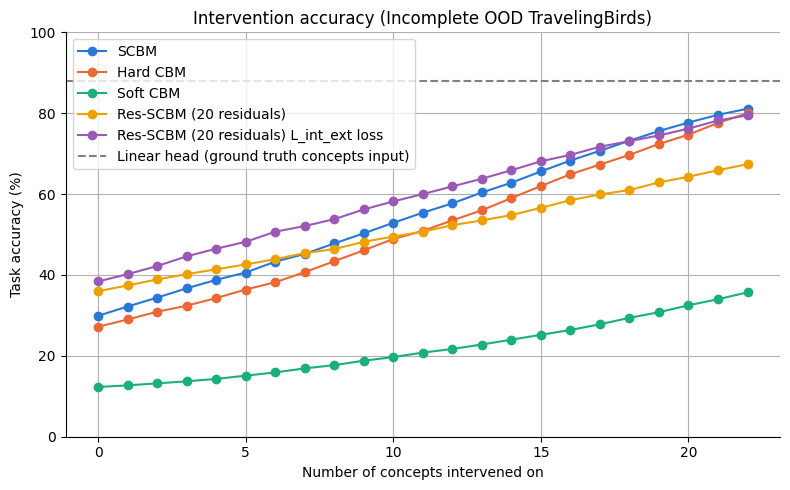

In [21]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [("SCBM", "Mateo_025_2026-08-10_17-06-22_5b4d7", "scbm"),
          ("Hard CBM", "Mateo_025_2026-08-10_17-07-25_84e08", "cbm"),
          ("Soft CBM", "Mateo_025_soft_cbm_2026-08-14_16-10-47_b1b9b", "cbm"),
          ("Res-SCBM (20 residuals)", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual"),
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]


colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

def plot(models, colors, title, linear_head_experiment=None, intervention_on_val_bool=False):


    fig, ax = plt.subplots(figsize=(8, 5))
    for (label, model_dir, model_type), color in zip(models, colors):
        concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
            model_dir, model_type=model_type, intervention_on_val=intervention_on_val_bool
        )
        ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

    # Linear head ground truth concepts input
    if linear_head_experiment is not None:
        linear_head = retrieve_acc_from_log(os.path.join("experiments", "linear_head", "CUB", linear_head_experiment), linear_model=True)[0]
        ax.axhline(y=linear_head, color="gray", linestyle="--", label="Linear head (ground truth concepts input)")

    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Task accuracy (%)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    # y_max = 100
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot(models, colors, "Intervention accuracy (Incomplete OOD TravelingBirds)", linear_head_experiment="Mateo_025_2026-05-06_12-41-45_15c1b")

In [22]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="TravelingBirds", return_auroc=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,29.9,89.9,92.5,91.2
1,SCBM,11,55.4,95.6,98.9,98.2
2,SCBM,22,81.1,100.0,99.9,100.0
3,Hard CBM,0,27.2,89.5,92.1,90.8
4,Hard CBM,11,50.9,94.7,98.6,97.7
5,Hard CBM,22,80.0,100.0,99.9,100.0
6,Soft CBM,0,12.3,89.8,89.4,91.1
7,Soft CBM,11,20.8,95.0,97.1,97.8
8,Soft CBM,22,35.7,100.0,99.6,100.0
9,Res-SCBM (20 residuals),0,36.0,90.1,94.2,91.3


## Incomplete ID TravelingBirds interventions

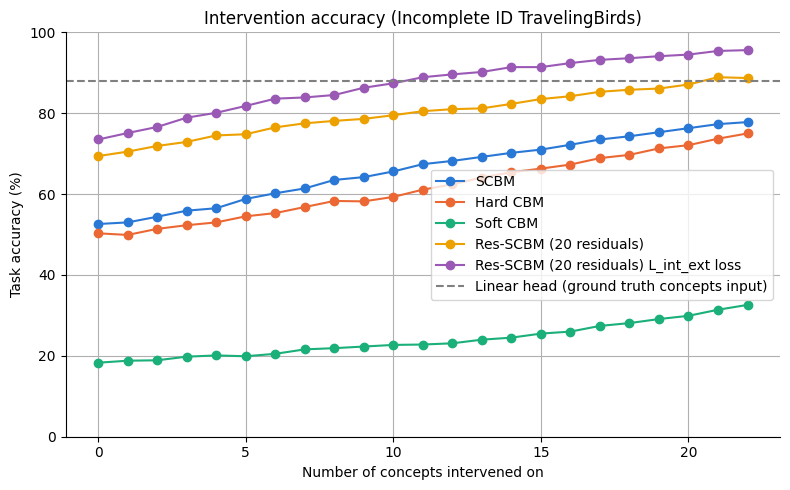

In [23]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [("SCBM", "Mateo_025_2026-08-10_17-06-22_5b4d7", "scbm"),
          ("Hard CBM", "Mateo_025_2026-08-10_17-07-25_84e08", "cbm"),
          ("Soft CBM", "Mateo_025_soft_cbm_2026-08-14_16-10-47_b1b9b", "cbm"),
          ("Res-SCBM (20 residuals)", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual"),
          
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

def plot(models, colors, title, linear_head_experiment=None, intervention_on_val_bool=False):


    fig, ax = plt.subplots(figsize=(8, 5))
    for (label, model_dir, model_type), color in zip(models, colors):
        concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
            model_dir, model_type=model_type, intervention_on_val=intervention_on_val_bool
        )
        ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

    # Linear head ground truth concepts input
    if linear_head_experiment is not None:
        linear_head = retrieve_acc_from_log(os.path.join("experiments", "linear_head", "CUB", linear_head_experiment), linear_model=True)[0]
        ax.axhline(y=linear_head, color="gray", linestyle="--", label="Linear head (ground truth concepts input)")

    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Task accuracy (%)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    # y_max = 100
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot(models, colors, "Intervention accuracy (Incomplete ID TravelingBirds)", linear_head_experiment="Mateo_025_2026-05-06_12-41-45_15c1b", intervention_on_val_bool=True)

In [24]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="TravelingBirds", return_auroc=True, intervention_on_val=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,52.6,94.5,96.9,97.4
1,SCBM,11,67.4,97.8,99.5,99.6
2,SCBM,22,77.8,100.0,99.9,100.0
3,Hard CBM,0,50.3,94.2,96.3,97.1
4,Hard CBM,11,61.1,97.0,99.2,99.2
5,Hard CBM,22,75.0,100.0,99.9,100.0
6,Soft CBM,0,18.3,94.1,94.5,96.9
7,Soft CBM,11,22.8,96.9,98.1,99.1
8,Soft CBM,22,32.6,100.0,99.5,100.0
9,Res-SCBM (20 residuals),0,69.4,94.6,98.4,97.5


### SCBM Residual model ID and OOD 

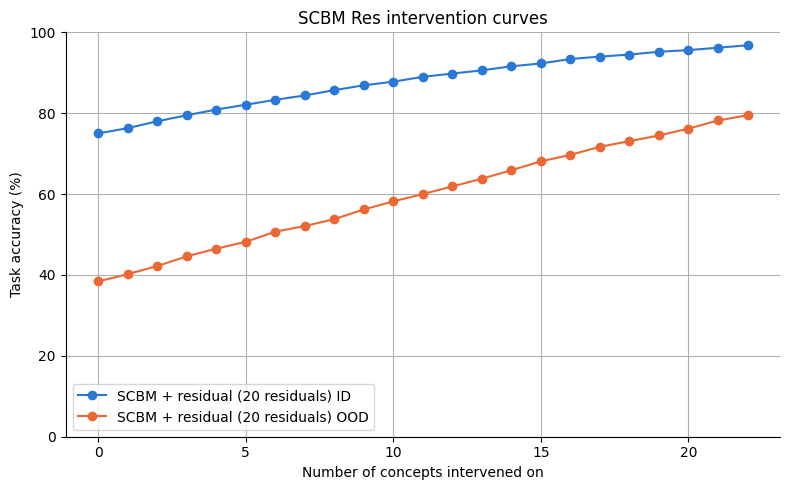

In [25]:
scbm_res_id_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed",
    model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True, folder="test_bg_train"
)

scbm_res_ood_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", 
    model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True, folder="test_bg_test"
)


# Plot the intervention curves for ID and OOD on the same plot
fig, ax = plt.subplots(figsize=(8, 5))
concepts_intervened_id, y_accuracies_id, c_accuracies_id, y_aurocs_id, c_aurocs_id = scbm_res_id_intervention
concepts_intervened_ood, y_accuracies_ood, c_accuracies_ood, y_aurocs_ood, c_aurocs_ood = scbm_res_ood_intervention 

# Plot ID intervention curve
ax.plot(concepts_intervened_id, y_accuracies_id, marker="o", color="#2a78d6", label="SCBM + residual (20 residuals) ID")
# Plot OOD intervention curve
ax.plot(concepts_intervened_ood, y_accuracies_ood, marker="o", color="#eb6834", label="SCBM + residual (20 residuals) OOD")

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("SCBM Res intervention curves")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()




## test_bg_test vs normal intervention_log curve

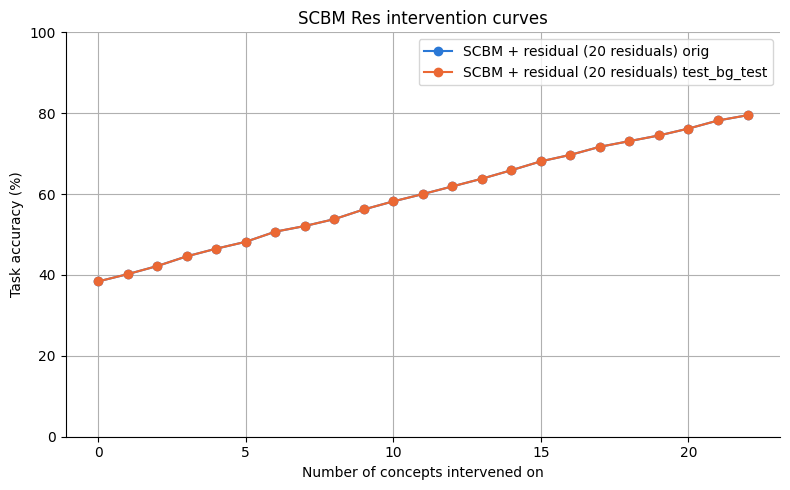

In [26]:
scbm_res_orig_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed",
    model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True
)

scbm_res_test_bg_test_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", 
    model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True, folder="test_bg_test"
)


# Plot the intervention curves for ID and OOD on the same plot
fig, ax = plt.subplots(figsize=(8, 5))
concepts_intervened_orig, y_accuracies_orig, c_accuracies_orig, y_aurocs_orig, c_aurocs_orig = scbm_res_orig_intervention
concepts_intervened_test_bg_test, y_accuracies_test_bg_test, c_accuracies_test_bg_test, y_aurocs_test_bg_test, c_aurocs_test_bg_test = scbm_res_test_bg_test_intervention 

# Plot ID intervention curve
ax.plot(concepts_intervened_orig, y_accuracies_orig, marker="o", color="#2a78d6", label="SCBM + residual (20 residuals) orig")
# Plot OOD intervention curve
ax.plot(concepts_intervened_test_bg_test, y_accuracies_test_bg_test, marker="o", color="#eb6834", label="SCBM + residual (20 residuals) test_bg_test")

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("SCBM Res intervention curves")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()




### Residual activation

In [27]:
primary_metric = "mean_abs_change" #"normalized_sensitivity"

In [28]:
NUM_CONCEPTS = 22

# ------------------------------------------------------------
# 1. Experiment paths
# ------------------------------------------------------------

EXPERIMENT_PATH = os.path.join(
    "experiments",
    "scbm_residual",
    "TravelingBirds",
    #"Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e"
    "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed"
)

test_bg_train_path = os.path.join(
    EXPERIMENT_PATH,
    "test_bg_train"
)

test_bg_test_path = os.path.join(
    EXPERIMENT_PATH,
    "test_bg_test"
)


# ------------------------------------------------------------
# 2. Load concept and residual means for both renders
# ------------------------------------------------------------

C_R_bg_train = torch.load(
    os.path.join(test_bg_train_path, "concepts_residuals_pred_probs_mean.pt"),
    map_location="cpu"
)

C_R_bg_test = torch.load(
    os.path.join(test_bg_test_path, "concepts_residuals_pred_probs_mean.pt"),
    map_location="cpu"
)

C_bg_train = C_R_bg_train[:, :NUM_CONCEPTS].detach().cpu().numpy()
C_bg_test  = C_R_bg_test[:,  :NUM_CONCEPTS].detach().cpu().numpy()

R_bg_train = C_R_bg_train[:, NUM_CONCEPTS:].detach().cpu().numpy()
R_bg_test  = C_R_bg_test[:,  NUM_CONCEPTS:].detach().cpu().numpy()

print("concepts:", C_bg_train.shape, " residuals:", R_bg_train.shape)

assert C_bg_train.shape == C_bg_test.shape
assert R_bg_train.shape == R_bg_test.shape

# Change this two image paths
# ------------------------------------------------------------
# 3. Verify the two renders are row-aligned 
# ------------------------------------------------------------


def rel_after_bg_root(path):
    """<...>/TravelingBirds/train/001.Black_footed_Albatross/x.jpg -> 001.Black_footed_Albatross/x.jpg

    Drops everything up to and including the last `train`/`test` folder component,
    so the two background renderings of the same photo compare equal.
    """
    parts = path.strip().split("/")
    i = max(idx for idx, part in enumerate(parts) if part in ("train", "test"))
    return "/".join(parts[i + 1:])


def read_img_paths(folder_path):
    with open(os.path.join(folder_path, "img_paths.txt"), "r") as f:
        return [rel_after_bg_root(line) for line in f if line.strip()]


img_paths_train = read_img_paths(test_bg_train_path)
img_paths_test = read_img_paths(test_bg_test_path)


# check the two renderings are row-aligned (same bird, same labels, different background)
if img_paths_train == img_paths_test:
    print(f"Row-aligned: {len(img_paths_train)} images match between test_bg_train and test_bg_test.")
else:
    n_mismatch = sum(a != b for a, b in zip(img_paths_train, img_paths_test))
    print(
        f"NOT aligned: {len(img_paths_train)} vs {len(img_paths_test)} rows, "
        f"{n_mismatch} mismatches in the overlap."
    )


concepts: (5794, 22)  residuals: (5794, 20)
Row-aligned: 5794 images match between test_bg_train and test_bg_test.


In [29]:
# ============================================================
# Shared background-swap analysis
#
# The concept and residual channels get exactly the same treatment,
# so it is written once here and applied to both. Both renders show
# the same bird with the same labels, so any movement between them is
# caused purely by the background.
# ============================================================


def channel_shift_stats(A_train, A_test, channel_name):
    """Per-dimension shift of one channel under the background swap."""

    d = A_train.shape[1]

    std = A_train.std(axis=0)
    mean_abs_activation = np.abs(A_train).mean(axis=0)
    mean_abs_change = np.abs(A_test - A_train).mean(axis=0)

    corr = np.array([
        np.corrcoef(A_train[:, j], A_test[:, j])[0, 1]
        for j in range(d)
    ])

    return pd.DataFrame({
        "channel": channel_name,
        "dim": np.arange(d),
        "std_bg_train": std,
        "mean_abs_activation": mean_abs_activation,
        "mean_abs_change": mean_abs_change,
        # shift in units of the dimension's own spread
        "normalized_sensitivity": mean_abs_change / (std + 1e-8),
        # shift relative to the dimension's typical activation magnitude
        "relative_change": mean_abs_change / (mean_abs_activation + 1e-8),
        "bg_swap_correlation": corr,
    })


def per_class_shift_stats(A_train, A_test, class_ids, channel_name):
    """Same shift, split by class.

    Normalized by the GLOBAL per-dimension std rather than a per-class one,
    so that different classes stay comparable to each other.
    """

    std = A_train.std(axis=0)
    rows = []

    for class_id in np.unique(class_ids):

        mask = class_ids == class_id

        mean_class_change = np.abs(
            A_test[mask] - A_train[mask]
        ).mean(axis=0)

        for dim in range(A_train.shape[1]):
            rows.append({
                "channel": channel_name,
                "class_id": int(class_id),
                "dim": dim,
                "mean_abs_change": mean_class_change[dim],
                "normalized_sensitivity":
                    mean_class_change[dim] / (std[dim] + 1e-8),
            })

    return pd.DataFrame(rows)


def plot_channel_shift(df, metric="normalized_sensitivity", ax=None):
    """Per-dimension bar plot of one channel's background sensitivity."""

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    plot_df = df.sort_values("dim")
    channel = plot_df["channel"].iloc[0]

    ax.bar(plot_df["dim"], plot_df[metric])
    ax.set_xticks(plot_df["dim"])
    ax.set_xlabel(f"{channel} dimension")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

    return ax


In [30]:
residual_shift_df = channel_shift_stats(R_bg_train, R_bg_test, "residual")
concept_shift_df  = channel_shift_stats(C_bg_train, C_bg_test, "concept")

shift_df = pd.concat(
    [concept_shift_df, residual_shift_df],
    ignore_index=True
)

residual_shift_df.sort_values(
    "normalized_sensitivity",
    ascending=False
)


,channel,dim,std_bg_train,mean_abs_activation,mean_abs_change,normalized_sensitivity,relative_change,bg_swap_correlation
12,residual,12,0.419727,0.577968,0.260679,0.621069,0.451028,0.533379
3,residual,3,0.423490,0.579084,0.255109,0.602397,0.440539,0.549309
9,residual,9,0.422935,0.579391,0.251607,0.594907,0.434261,0.560464
17,residual,17,0.424347,0.569966,0.250743,0.590891,0.439926,0.567012
16,residual,16,0.423174,0.566550,0.248995,0.588398,0.439492,0.568151
0,residual,0,0.427343,0.591511,0.251363,0.588201,0.424951,0.560248
10,residual,10,0.421730,0.596124,0.244166,0.578964,0.409590,0.574830
4,residual,4,0.427442,0.571165,0.247364,0.578708,0.433087,0.571936
14,residual,14,0.423351,0.592480,0.244314,0.577094,0.412357,0.569883
8,residual,8,0.423311,0.568290,0.240327,0.567731,0.422895,0.593269


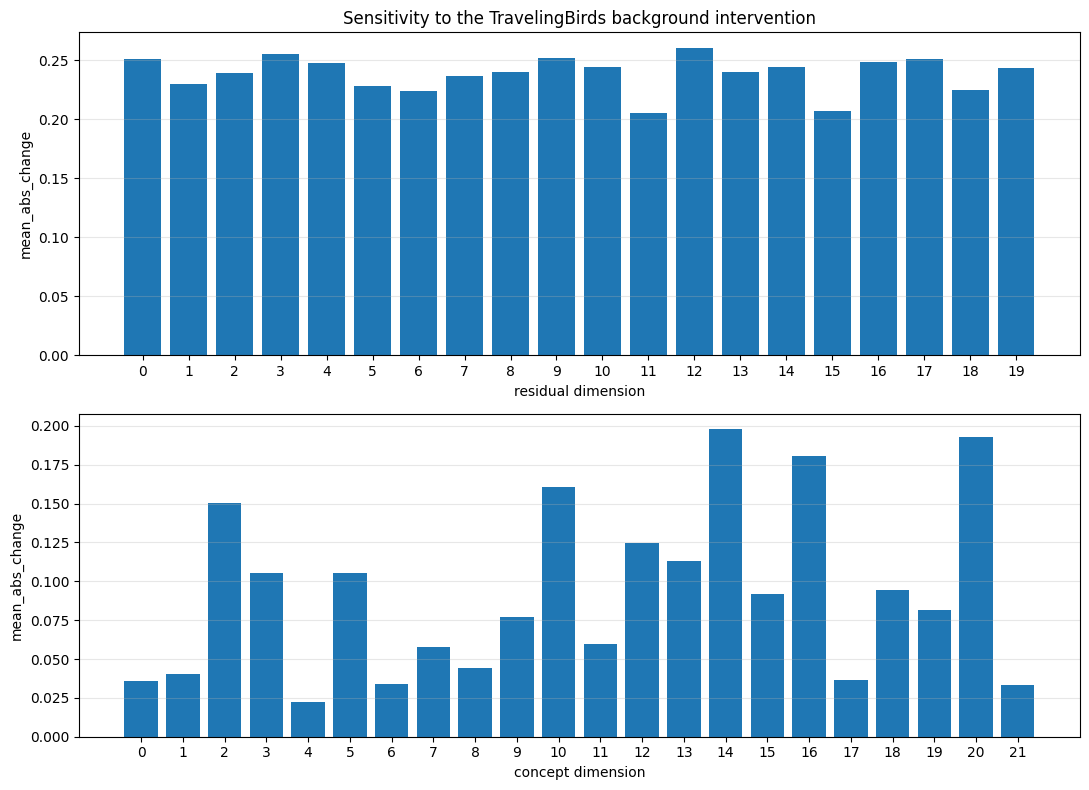

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

for ax, df in zip(axes, (residual_shift_df, concept_shift_df)):
    plot_channel_shift(df, metric=primary_metric, ax=ax)

axes[0].set_title(
    "Sensitivity to the TravelingBirds background intervention"
)

fig.tight_layout()
plt.show()


### Per sample shift

In [ ]:
y_true_test_bg_test = torch.load(os.path.join(test_bg_test_path, "y_true.pt"))
y_true_test_bg_train = torch.load(os.path.join(test_bg_train_path, "y_true.pt"))

assert torch.equal(y_true_test_bg_test, y_true_test_bg_train), "y_true labels do not match between test_bg_test and test_bg_train"

c_r_prob_test_bg_test = torch.load(os.path.join(test_bg_test_path, "concepts_residuals_pred_probs.pt"))
c_r_prob_test_bg_train = torch.load(os.path.join(test_bg_train_path, "concepts_residuals_pred_probs.pt"))






### Per class shift following background shift

In [44]:
# Function to get per class accuracy

# ============================================================
# Per-class task accuracy
# ============================================================

import numpy as np
import pandas as pd
import torch


def get_per_class_accuracy(y_true, y_pred, num_classes=None):
    """Top-1 accuracy split by true class.

    Parameters
    ----------
    y_true : [N] tensor/array of integer class labels.
    y_pred : either [N, K] logits (argmaxed here) or [N] predicted
        class indices.
    num_classes : number of classes. Inferred from the logits when
        y_pred is 2D, otherwise from the labels themselves -- pass it
        explicitly if a class may be absent from this split.

    Returns
    -------
    DataFrame with one row per class: class_id, num_samples,
    num_correct, accuracy. Classes with no samples get accuracy NaN
    rather than 0, so they can be dropped instead of dragging a mean
    down.
    """

    y_true = torch.as_tensor(y_true).detach().cpu().long().view(-1)
    y_pred = torch.as_tensor(y_pred).detach().cpu()

    # Logits for each class? Argmax to get predicted class index.
    if y_pred.ndim == 2:
        if num_classes is None:
            num_classes = y_pred.shape[1]
        assert y_pred.shape[1] == num_classes, (
            f"y_pred has {y_pred.shape[1]} classes, "
            f"but num_classes={num_classes}."
        )
        y_pred = y_pred.argmax(dim=1)
    else:
        y_pred = y_pred.long().view(-1)
        if num_classes is None:
            num_classes = int(y_true.max().item()) + 1

    assert y_pred.shape[0] == y_true.shape[0], (
        f"y_pred has {y_pred.shape[0]} samples, "
        f"but y_true has {y_true.shape[0]}."
    )

    assert y_true.min().item() >= 0
    assert y_true.max().item() < num_classes

    correct = (y_pred == y_true)

    rows = []

    for class_idx in range(num_classes):
        class_mask = y_true == class_idx
        class_count = int(class_mask.sum().item())
        class_correct = int(correct[class_mask].sum().item())

        rows.append({
            "class_id": class_idx,
            "num_samples": class_count,
            "num_correct": class_correct,
            "accuracy": (
                class_correct / class_count
                if class_count > 0
                else float("nan")
            ),
        })

    return pd.DataFrame(rows)


In [47]:
# Get accuracy of ID and OOD renders for SCBM + residual (20 residuals) with L_int_ext loss weight 1
y_true_test_bg_train = torch.load(os.path.join(test_bg_train_path, "y_true.pt"), map_location="cpu")
y_pred_test_bg_train = torch.load(os.path.join(test_bg_train_path, "y_pred.pt"), map_location="cpu")

y_true_test_bg_test = torch.load(os.path.join(test_bg_test_path, "y_true.pt"), map_location="cpu")
y_pred_test_bg_test = torch.load(os.path.join(test_bg_test_path, "y_pred.pt"), map_location="cpu")

test_bg_train_acc_df = get_per_class_accuracy(y_true_test_bg_train, y_pred_test_bg_train)
test_bg_test_acc_df = get_per_class_accuracy(y_true_test_bg_test, y_pred_test_bg_test)

test_bg_train_acc_df.head(10)


,class_id,num_samples,num_correct,accuracy
0,0,30,24,0.800000
1,1,30,18,0.600000
2,2,28,24,0.857143
3,3,30,27,0.900000
4,4,14,11,0.785714
5,5,11,9,0.818182
6,6,23,21,0.913043
7,7,18,12,0.666667
8,8,29,25,0.862069
9,9,30,27,0.900000


In [32]:
y_test_bg = torch.load(os.path.join(test_bg_test_path, "y_true.pt"))

In [50]:
per_class_shift_df = pd.concat(
    [
        per_class_shift_stats(C_bg_train, C_bg_test, y_test_bg, "concept"),
        per_class_shift_stats(R_bg_train, R_bg_test, y_test_bg, "residual"),
    ],
    ignore_index=True
)

# Add per-class accuracy for both renders of the same birds.
#   ID  = test_bg_train -> TravelingBirds/train/, class-correlated background
#   OOD = test_bg_test  -> TravelingBirds/test/,  random background
# Same photos and same labels in both, so accuracy_ood - accuracy_id is the
# background-induced drop for that class, directly comparable to the activation
# shift columns computed above.
per_class_shift_df = per_class_shift_df.merge(
    test_bg_train_acc_df[["class_id", "accuracy"]].rename(
        columns={"accuracy": "class_accuracy_id"}
    ),
    on="class_id",
    how="left",
).merge(
    test_bg_test_acc_df[["class_id", "accuracy"]].rename(
        columns={"accuracy": "class_accuracy_ood"}
    ),
    on="class_id",
    how="left",
)

# Negative = the class loses accuracy when the background is randomized.
per_class_shift_df["class_accuracy_drop"] = (
    per_class_shift_df["class_accuracy_ood"]
    - per_class_shift_df["class_accuracy_id"]
)


# Rank the dimensions by background sensitivity WITHIN each class, so reading
# down a class block gives that class's most background-sensitive dimensions
# first. Both channels are ranked against each other: they are MC-mean Bernoulli
# probabilities feeding the same head, so mean_abs_change carries the same units
# in either block. Read the `channel` column alongside `dim`, which restarts at
# 0 per channel.
per_class_shift_df = per_class_shift_df.sort_values(
    ["class_id", "mean_abs_change"],
    ascending=[True, False],
).reset_index(drop=True)

display(per_class_shift_df)

,channel,class_id,dim,mean_abs_change,normalized_sensitivity,class_accuracy_id,class_accuracy_ood,class_accuracy_drop
0,concept,0,1,0.438745,2.282218,0.8,0.333333,-0.466667
1,concept,0,20,0.371806,0.831220,0.8,0.333333,-0.466667
2,residual,0,18,0.337382,0.813133,0.8,0.333333,-0.466667
3,residual,0,5,0.336468,0.783713,0.8,0.333333,-0.466667
4,residual,0,8,0.331091,0.782146,0.8,0.333333,-0.466667
...,...,...,...,...,...,...,...,...
8395,concept,199,7,0.000797,0.003765,0.9,0.400000,-0.500000
8396,concept,199,17,0.000791,0.004096,0.9,0.400000,-0.500000
8397,concept,199,0,0.000551,0.002476,0.9,0.400000,-0.500000
8398,concept,199,6,0.000512,0.002550,0.9,0.400000,-0.500000


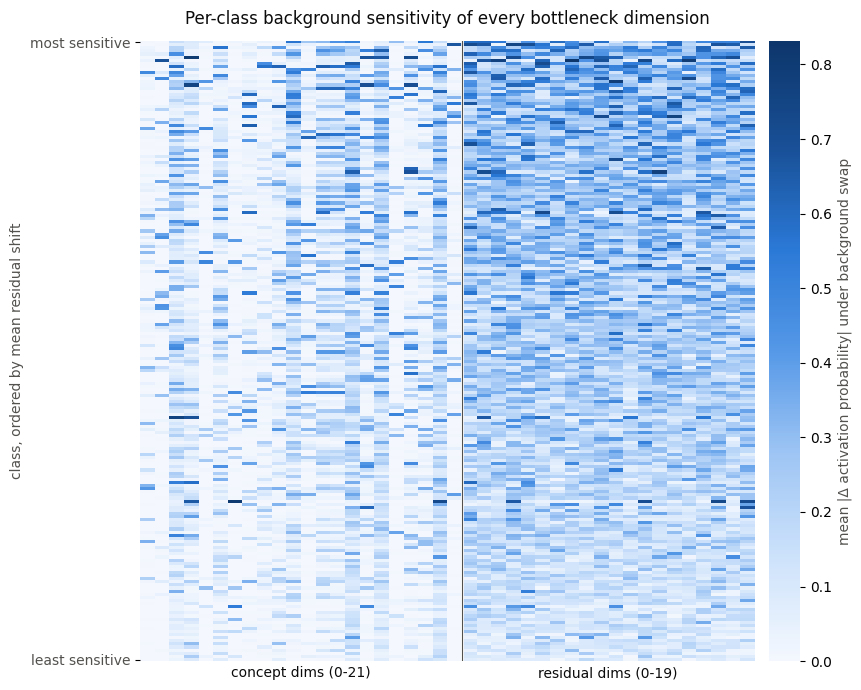

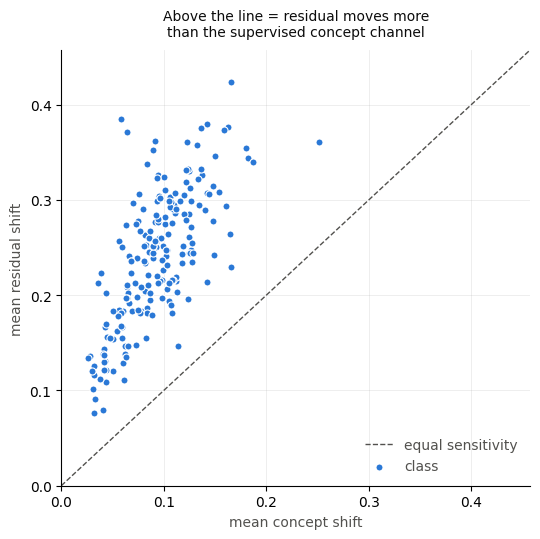

channel,concept,residual
count,200.000,200.000
mean,0.093,0.238
std,0.036,0.071
min,0.026,0.076
25%,0.065,0.186
50%,0.092,0.243
75%,0.114,0.291
max,0.251,0.423


In [34]:
# ============================================================
# Class-wise view of the background-swap shift
# ============================================================
#
# Two forms, both reading `mean_abs_change` (units: activation probability,
# so concept and residual dimensions are directly comparable):
#
#   1. heatmap  - classes x every bottleneck dimension; shows *which* dims
#                 carry a class's background sensitivity.
#   2. scatter  - one point per class; shows *how much* the residual channel
#                 moves relative to the concept channel, which is supervised
#                 to be background-invariant and therefore acts as a floor.

from matplotlib.colors import LinearSegmentedColormap


# Single-hue sequential ramp: near-zero recedes into the surface, larger
# shift = darker. Magnitude data, so no diverging midpoint and no rainbow.
SHIFT_CMAP = LinearSegmentedColormap.from_list(
    "shift_blue",
    ["#f4f8fe", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"],
)

INK = "#0b0b0b"
INK_MUTED = "#52514e"


def plot_class_dim_heatmap(df, metric="mean_abs_change", order_by="residual"):
    """Classes x bottleneck dimensions, coloured by background-swap shift."""

    grid = df.pivot_table(
        index="class_id",
        columns=["channel", "dim"],
        values=metric,
    ).sort_index(axis=1)

    # Order classes by how background-sensitive `order_by` is on average, so
    # class-level structure shows up as a gradient instead of noise.
    class_order = grid[order_by].mean(axis=1).sort_values(ascending=False).index
    grid = grid.loc[class_order]

    n_concept = grid["concept"].shape[1]
    n_residual = grid.shape[1] - n_concept

    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(
        grid.values,
        aspect="auto",
        cmap=SHIFT_CMAP,
        vmin=0,
        interpolation="nearest",
    )

    # Separate the two channel blocks; dim indices restart at 0 per channel.
    ax.axvline(n_concept - 0.5, color="white", lw=2)
    ax.axvline(n_concept - 0.5, color=INK_MUTED, lw=0.8)

    ax.set_xticks([n_concept / 2 - 0.5, n_concept + n_residual / 2 - 0.5])
    ax.set_xticklabels(
        [f"concept dims (0-{n_concept - 1})", f"residual dims (0-{n_residual - 1})"],
        color=INK,
    )
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(f"class, ordered by mean {order_by} shift", color=INK_MUTED)
    ax.set_yticks([0, len(class_order) - 1])
    ax.set_yticklabels(["most sensitive", "least sensitive"], color=INK_MUTED)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(
        "mean |\u0394 activation probability| under background swap",
        color=INK_MUTED,
    )
    cbar.outline.set_visible(False)

    ax.set_title(
        "Per-class background sensitivity of every bottleneck dimension",
        color=INK,
        pad=12,
    )

    fig.tight_layout()
    return fig, ax, grid


def plot_class_channel_scatter(df, metric="mean_abs_change"):
    """One point per class: mean concept shift vs mean residual shift."""

    per_class = (
        df.groupby(["class_id", "channel"])[metric].mean().unstack("channel")
    )

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    lim = float(per_class.to_numpy().max()) * 1.08

    ax.plot(
        [0, lim], [0, lim],
        color=INK_MUTED, lw=1, ls="--", zorder=1,
        label="equal sensitivity",
    )
    ax.scatter(
        per_class["concept"], per_class["residual"],
        s=26, color="#2a78d6", edgecolor="white", linewidth=0.8,
        zorder=2, label="class",
    )

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("mean concept shift", color=INK_MUTED)
    ax.set_ylabel("mean residual shift", color=INK_MUTED)
    ax.set_title(
        "Above the line = residual moves more\nthan the supervised concept channel",
        color=INK, fontsize=10, pad=10,
    )
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False, loc="lower right", labelcolor=INK_MUTED)

    fig.tight_layout()
    return fig, ax, per_class


_, _, shift_grid = plot_class_dim_heatmap(per_class_shift_df)
plt.show()

_, _, per_class_channel_means = plot_class_channel_scatter(per_class_shift_df)
plt.show()

display(
    per_class_channel_means.describe().round(3)
)

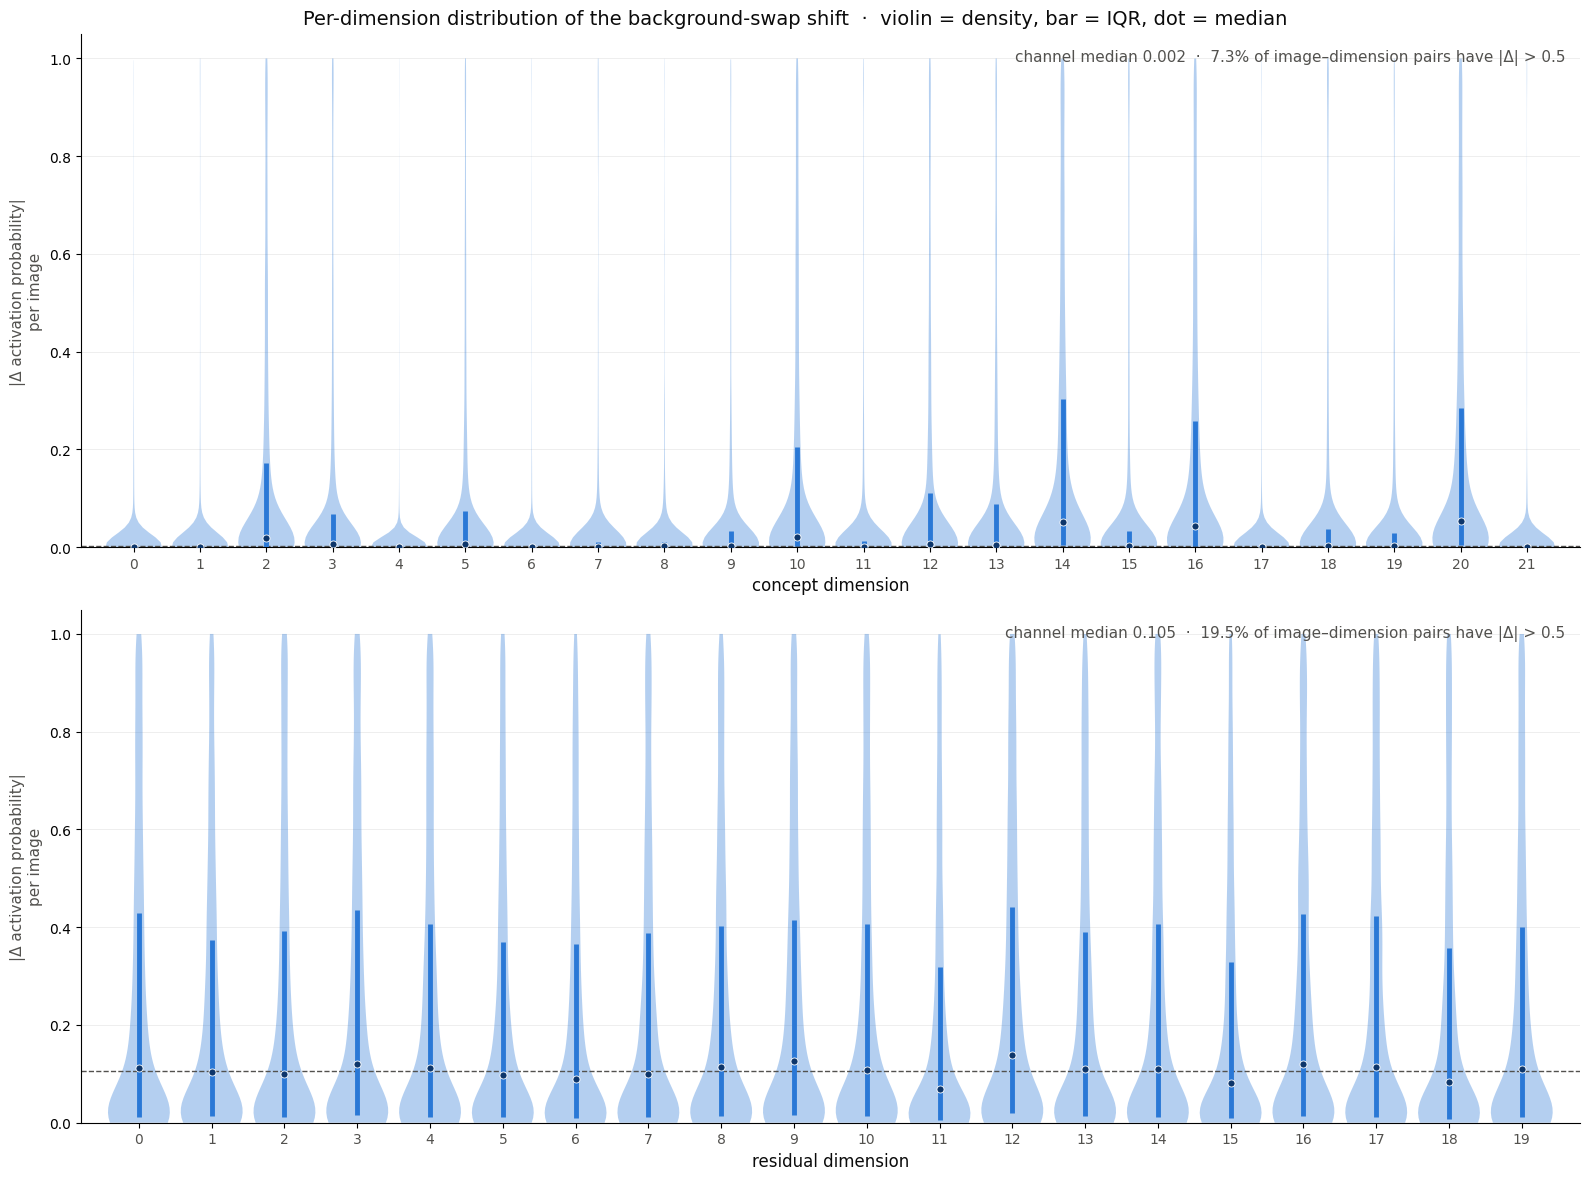

 concept: median 0.002 | mean 0.093 | P(>0.5) 7.3% | per-dim medians 0.000-0.053
residual: median 0.105 | mean 0.239 | P(>0.5) 19.5% | per-dim medians 0.069-0.138


In [35]:
# ============================================================
# Per-dimension distribution of the background-swap shift
# ============================================================
#
# One violin per dimension, over the paired renders: every image contributes
# |p_bg_test - p_bg_train| for that dimension. This is the distribution the
# per-class `mean_abs_change` table aggregates away -- these shifts are
# strongly zero-inflated with a tail all the way to 1.0, so a mean alone
# hides both the "mostly does not move" mass and the outright flips.
#
# Both panels share the y-axis: concept and residual dimensions are activation
# probabilities feeding the same head, so the scale is common.


# Palette constants, repeated here so this cell runs standalone.
INK = "#0b0b0b"
INK_MUTED = "#52514e"
HUE = "#2a78d6"        # sequential blue, same hue as the class-wise heatmap
HUE_DARK = "#0d366b"   # darkest step, for the median marker


def plot_abs_change_distributions(pairs, metric_name="|Δ activation probability|"):
    """Per-dimension distribution of the background-swap shift.

    pairs: list of (channel_name, A_bg_train, A_bg_test), one panel each.
    """

    deltas = [(name, np.abs(test - train)) for name, train, test in pairs]

    # Stacked vertically, one panel per channel, on a shared y-axis: the two
    # channels stay directly comparable while each panel gets the full width.
    fig, axes = plt.subplots(
        len(deltas), 1,
        figsize=(16, 6.0 * len(deltas)),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, (name, delta) in zip(axes, deltas):

        d = delta.shape[1]
        positions = np.arange(d)

        parts = ax.violinplot(
            [delta[:, j] for j in positions],
            positions=positions,
            widths=0.85,
            showextrema=False,
            showmedians=False,
        )
        for body in parts["bodies"]:
            body.set_facecolor(HUE)
            body.set_alpha(0.35)
            body.set_edgecolor("none")

        # Median + IQR over the density, so the summary is readable without
        # hiding the shape of the distribution.
        q1, med, q3 = np.percentile(delta, [25, 50, 75], axis=0)
        ax.vlines(positions, q1, q3, color=HUE, lw=3.5, zorder=3)
        ax.scatter(positions, med, s=26, color=HUE_DARK, zorder=4,
                   edgecolor="white", linewidth=0.6)

        ax.set_xticks(positions)
        ax.set_xticklabels(positions, fontsize=10, color=INK_MUTED)
        ax.set_xlabel(f"{name} dimension", color=INK, fontsize=12)
        ax.set_xlim(-0.8, d - 0.2)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        # Channel-level median, labelled at a fixed corner so it never
        # collides with the axis when the median sits near zero.
        ax.axhline(np.median(delta), color=INK_MUTED, lw=1, ls="--", zorder=2)
        ax.annotate(
            f"channel median {np.median(delta):.3f}"
            f"  ·  {(delta > 0.5).mean():.1%} of image–dimension pairs have |Δ| > 0.5",
            xy=(0.99, 0.97), xycoords="axes fraction",
            ha="right", va="top", fontsize=11, color=INK_MUTED,
        )

    for ax in axes:
        ax.set_ylabel(f"{metric_name}\nper image", color=INK_MUTED, fontsize=11)
        ax.tick_params(axis="y", labelsize=10)
    axes[0].set_ylim(bottom=0)

    fig.suptitle(
        "Per-dimension distribution of the background-swap shift"
        "  ·  violin = density, bar = IQR, dot = median",
        color=INK, fontsize=14,
    )
    fig.tight_layout()
    return fig, axes


fig, axes = plot_abs_change_distributions([
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
])
plt.show()


# Numeric companion to the figure.
for name, train, test in [
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
]:
    delta = np.abs(test - train)
    print(
        f"{name:>8}: median {np.median(delta):.3f} | mean {delta.mean():.3f} | "
        f"P(>0.5) {(delta > 0.5).mean():.1%} | "
        f"per-dim medians {np.median(delta, axis=0).min():.3f}-"
        f"{np.median(delta, axis=0).max():.3f}"
    )

### Per-dimension numbers behind the violins

The violin figure shows the *shape* of each dimension's background-swap shift;
these two cells give the numbers and the unpacked distributions.

* the table is one row per bottleneck dimension (`dim` restarts at 0 per
  `channel`) with `mean` / `median` / `min` / `max` of
  `|p_bg_test - p_bg_train|` over the paired renders, plus `std`, the quartiles
  and the flip rate `frac_gt_0.5`;
* the small-multiples grid is one histogram per dimension, log-count so the
  zero spike does not swallow the tail.

`min` is near-zero for essentially every dimension and `max` saturates at 1.0 on
at least one image for most of them &mdash; both are order statistics over ~6k
images, so they describe the extremes, not the behaviour. `median` vs `mean` and
`frac_gt_0.5` are what separate the channels.


In [36]:
# ============================================================
# Per-dimension summary of the background-swap shift
# ============================================================
#
# One row per bottleneck dimension, over the same paired renders the violins
# above are drawn from: every image contributes |p_bg_test - p_bg_train| for
# that dimension, and the row summarises that distribution. Concept and
# residual rows are directly comparable -- both are activation probabilities
# feeding the same head -- but `dim` restarts at 0 per channel, so always read
# it next to `channel`.
#
# Read `median` against `mean`: the shifts are zero-inflated, so a median near
# zero with a mean well above it means the dimension holds still on most images
# and flips on a few. `max` is a single-image worst case over ~1e4 images, not
# a trend -- `q75` and `frac_gt_0.5` are the honest tail summaries.


def per_dim_delta_summary(pairs):
    """Per-dimension summary of |Delta activation probability| under the swap.

    pairs: list of (channel_name, A_bg_train, A_bg_test), same argument shape
    as `plot_abs_change_distributions`.
    """

    rows = []

    for name, train, test in pairs:

        delta = np.abs(test - train)
        q25, med, q75 = np.percentile(delta, [25, 50, 75], axis=0)

        for j in range(delta.shape[1]):
            rows.append({
                "channel": name,
                "dim": j,
                "mean": delta[:, j].mean(),
                "median": med[j],
                "min": delta[:, j].min(),
                "max": delta[:, j].max(),
                "std": delta[:, j].std(),
                "q25": q25[j],
                "q75": q75[j],
                "frac_gt_0.5": (delta[:, j] > 0.5).mean(),
            })

    return pd.DataFrame(rows)


delta_summary_df = per_dim_delta_summary([
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
])

# Full table, in channel/dim order -- the companion to the violin figure.
display(delta_summary_df.round(4))

# Channel-level aggregate of the same numbers.
display(
    delta_summary_df
    .groupby("channel")[["mean", "median", "min", "max", "frac_gt_0.5"]]
    .agg(["mean", "min", "max"])
    .round(4)
)

# Most background-sensitive dimensions of either channel first.
display(
    delta_summary_df
    .sort_values("median", ascending=False)
    .round(4)
    .head(15)
)

delta_summary_df.to_csv(
    "TravelingBirds_analysis/per_dim_delta_summary.csv", index=False
)

,channel,dim,mean,median,min,max,std,q25,q75,frac_gt_0.5
0,concept,0,0.0361,0.0004,0.0,0.9963,0.1350,0.0000,0.0034,0.0287
1,concept,1,0.0406,0.0003,0.0,0.9999,0.1546,0.0000,0.0022,0.0338
2,concept,2,0.1506,0.0182,0.0,0.9999,0.2539,0.0010,0.1731,0.1220
3,concept,3,0.1054,0.0057,0.0,1.0000,0.2249,0.0004,0.0679,0.0820
4,concept,4,0.0223,0.0002,0.0,0.9992,0.1121,0.0000,0.0012,0.0181
5,concept,5,0.1052,0.0060,0.0,1.0000,0.2164,0.0006,0.0745,0.0797
6,concept,6,0.0336,0.0004,0.0,0.9998,0.1376,0.0001,0.0026,0.0283
7,concept,7,0.0578,0.0014,0.0,1.0000,0.1796,0.0002,0.0099,0.0454
8,concept,8,0.0445,0.0015,0.0,0.9993,0.1443,0.0002,0.0102,0.0314
9,concept,9,0.0768,0.0033,0.0,0.9980,0.1898,0.0004,0.0332,0.0573


mean                  median                  min            \
            mean     min     max    mean     min     max mean  min  max   
channel                                                                   
concept   0.0927  0.0223  0.1979  0.0104  0.0002  0.0531  0.0  0.0  0.0   
residual  0.2387  0.2051  0.2607  0.1059  0.0693  0.1377  0.0  0.0  0.0   

             max              frac_gt_0.5                  
            mean     min  max        mean     min     max  
channel                                                    
concept   0.9995  0.9963  1.0      0.0734  0.0181  0.1581  
residual  0.9999  0.9994  1.0      0.1948  0.1590  0.2180

,channel,dim,mean,median,min,max,std,q25,q75,frac_gt_0.5
34,residual,12,0.2607,0.1377,0.0,1.0000,0.2896,0.0192,0.4418,0.2180
31,residual,9,0.2516,0.1259,0.0,0.9999,0.2870,0.0163,0.4157,0.2047
25,residual,3,0.2551,0.1209,0.0,1.0000,0.2934,0.0155,0.4348,0.2128
38,residual,16,0.2490,0.1192,0.0,0.9998,0.2879,0.0141,0.4264,0.2061
30,residual,8,0.2403,0.1149,0.0,1.0000,0.2815,0.0145,0.4020,0.1919
39,residual,17,0.2507,0.1141,0.0,1.0000,0.2916,0.0120,0.4238,0.2109
22,residual,0,0.2514,0.1120,0.0,0.9997,0.2948,0.0120,0.4283,0.2114
26,residual,4,0.2474,0.1112,0.0,1.0000,0.2925,0.0121,0.4062,0.2045
41,residual,19,0.2434,0.1105,0.0,0.9999,0.2887,0.0126,0.3999,0.1983
35,residual,13,0.2404,0.1096,0.0,1.0000,0.2828,0.0145,0.3910,0.1954


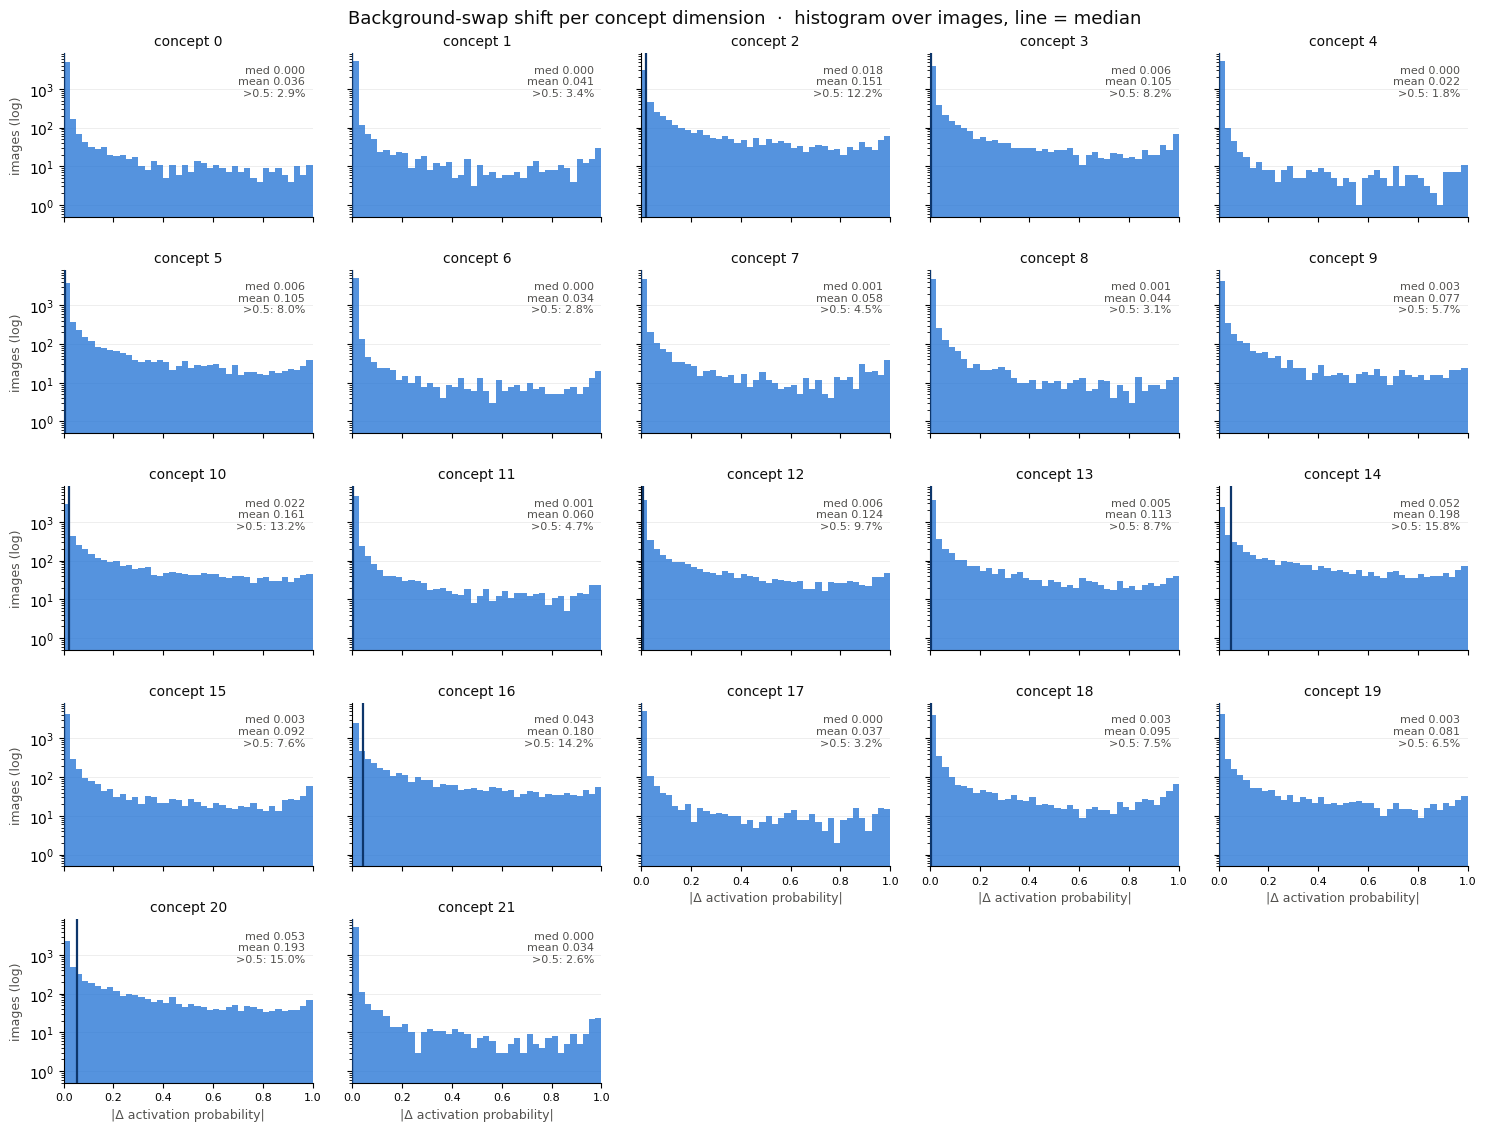

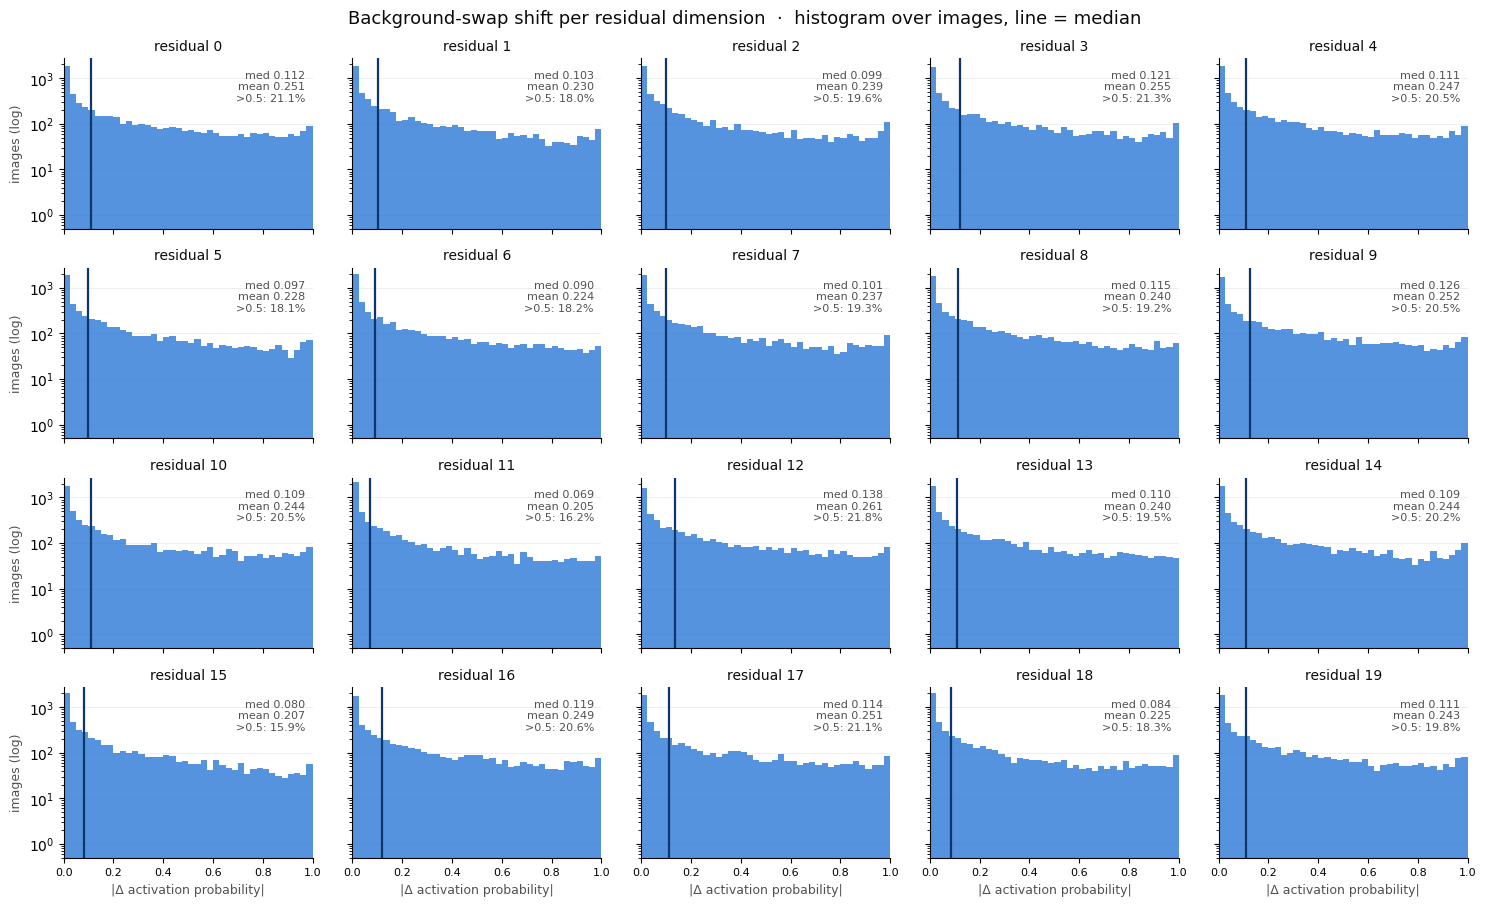

In [37]:
# ============================================================
# One panel per dimension: the full shape behind each violin
# ============================================================
#
# The violin figure compresses each dimension into a density strip; this is the
# same data unpacked, one histogram per dimension, so the zero spike and the
# tail can be read separately. Axes are shared across every panel of both
# figures (x on [0, 1], same y), so panels stay comparable at a glance.
#
# The count axis is logarithmic on purpose: the distributions are strongly
# zero-inflated, and on a linear axis the near-zero bin flattens everything
# else into the baseline -- exactly the tail these figures exist to show.

# Palette constants, repeated here so this cell runs standalone.
INK = "#0b0b0b"
INK_MUTED = "#52514e"
HUE = "#2a78d6"
HUE_DARK = "#0d366b"


def plot_per_dim_delta_grid(name, A_train, A_test, ncols=5, bins=40):
    """Small multiples of |Delta activation probability|, one panel per dim."""

    delta = np.abs(A_test - A_train)
    d = delta.shape[1]
    nrows = int(np.ceil(d / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.0 * ncols, 2.3 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    edges = np.linspace(0.0, 1.0, bins + 1)

    for j in range(d):

        ax = axes[j]
        ax.hist(delta[:, j], bins=edges, color=HUE, alpha=0.8, edgecolor="none")

        med = np.median(delta[:, j])
        ax.axvline(med, color=HUE_DARK, lw=1.6, zorder=3)

        ax.set_title(f"{name} {j}", fontsize=10, color=INK)
        ax.annotate(
            f"med {med:.3f}\nmean {delta[:, j].mean():.3f}"
            f"\n>0.5: {(delta[:, j] > 0.5).mean():.1%}",
            xy=(0.97, 0.93), xycoords="axes fraction",
            ha="right", va="top", fontsize=8, color=INK_MUTED,
        )

        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        # Bottom-most populated panel of each column carries the x-axis; with
        # a partially filled last row `sharex` would otherwise hide the ticks
        # on the panels sitting above the blanks.
        if j >= d - ncols:
            ax.set_xlabel("|Δ activation probability|", fontsize=9,
                          color=INK_MUTED)
            ax.tick_params(axis="x", labelbottom=True, labelsize=8)
        if j % ncols == 0:
            ax.set_ylabel("images (log)", fontsize=9, color=INK_MUTED)

    # Trailing panels of an incomplete last row carry no data.
    for ax in axes[d:]:
        ax.set_visible(False)

    axes[0].set_yscale("log")
    axes[0].set_ylim(bottom=0.5)
    axes[0].set_xlim(0.0, 1.0)

    fig.suptitle(
        f"Background-swap shift per {name} dimension"
        "  ·  histogram over images, line = median",
        color=INK, fontsize=13,
    )
    fig.tight_layout()
    return fig, axes


for _name, _train, _test in [
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
]:
    plot_per_dim_delta_grid(_name, _train, _test)
    plt.show()

### Baseline: the concept channel under the same background swap

The residual shift has no scale of its own. The concept channel supplies one,
measured on the *same* paired renders with the *same* function: same bird, same
labels, so the ground-truth attributes are identical and the BCE term actively
trains this channel to be background-invariant. Any concept movement is
background leakage into a channel that was told not to have it.

That makes it a **floor, not a neutral control**. The honest reading is *"is the
residual more background-sensitive than a channel explicitly supervised to be
invariant?"* &mdash; not *"more sensitive than a channel would be by default"*.

Reading the three metrics:

* `normalized_sensitivity` &mdash; the *share* of a dimension's total variation that
  is background-driven, not how far it moves. A near-collapsed dimension tops
  this ranking on a trivial absolute shift, so read `std_bg_train` and
  `mean_abs_change` next to it.
* `relative_change` &mdash; shift against typical activation magnitude; same caveat
  for dimensions that sit near zero.
* `bg_swap_correlation` &mdash; scale-free, so it is the one to trust when the other
  two disagree.

         normalized_sensitivity        relative_change         \
                           mean median            mean median   
channel                                                         
concept                   0.273  0.273           0.590  0.566   
residual                  0.562  0.567           0.413  0.420   

         bg_swap_correlation         
                        mean median  
channel                              
concept                0.715  0.728  
residual               0.591  0.589  


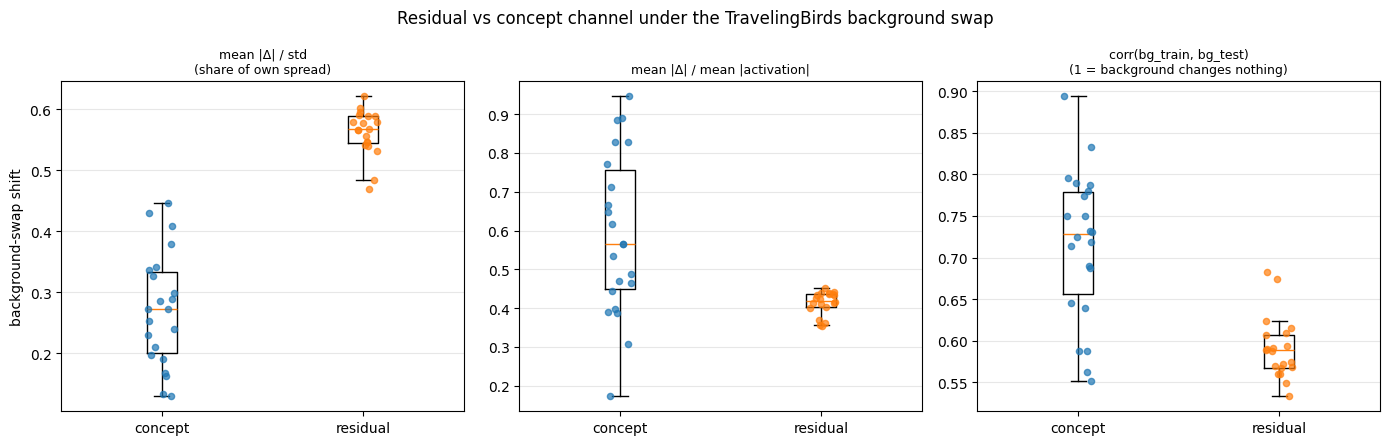

In [38]:
METRICS = [
    "normalized_sensitivity",
    "relative_change",
    "bg_swap_correlation",
]

print(
    shift_df
    .groupby("channel")[METRICS]
    .agg(["mean", "median"])
    .round(3)
)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = [
    "mean |\u0394| / std\n(share of own spread)",
    "mean |\u0394| / mean |activation|",
    "corr(bg_train, bg_test)\n(1 = background changes nothing)",
]

rng = np.random.default_rng(0)

for ax, metric, label in zip(axes, METRICS, labels):

    data = [
        shift_df.loc[shift_df["channel"] == ch, metric].values
        for ch in ("concept", "residual")
    ]

    ax.boxplot(data, showfliers=False)

    for i, vals in enumerate(data, start=1):
        ax.scatter(
            i + rng.uniform(-0.07, 0.07, vals.size),
            vals,
            s=20,
            alpha=0.7,
            zorder=3
        )

    ax.set_xticks([1, 2], ["concept", "residual"])
    ax.set_title(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("background-swap shift")

fig.suptitle(
    "Residual vs concept channel under the TravelingBirds background swap"
)
fig.tight_layout()
plt.show()


## Concept Auroc

In [53]:
def plot_concept_auroc(models, colors, title):


    fig, ax = plt.subplots(figsize=(8, 5))

    for model, color in zip(models, colors):
        label, model_dir, model_type = model[0], model[1], model[2]
        dataset = model[3] if len(model) > 3 else "TravelingBirds"
        model_folder = model[4] if len(model) > 4 else None

        concepts_intervened, y_accuracies, c_accuracies, c_auroc = extract_info_from_intervention_log(
            model_dir,
            model_type=model_type,
            dataset=dataset,
            return_c_auroc=True,
            folder=model_folder,
        )
        ax.plot(concepts_intervened, c_auroc, marker="o", color=color, label=label)

    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Concept AUROC")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    ax.set_ylim(90, 105)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return fig, ax

### Incomplete ID and OOD TravelingBirds and CUB concept auroc

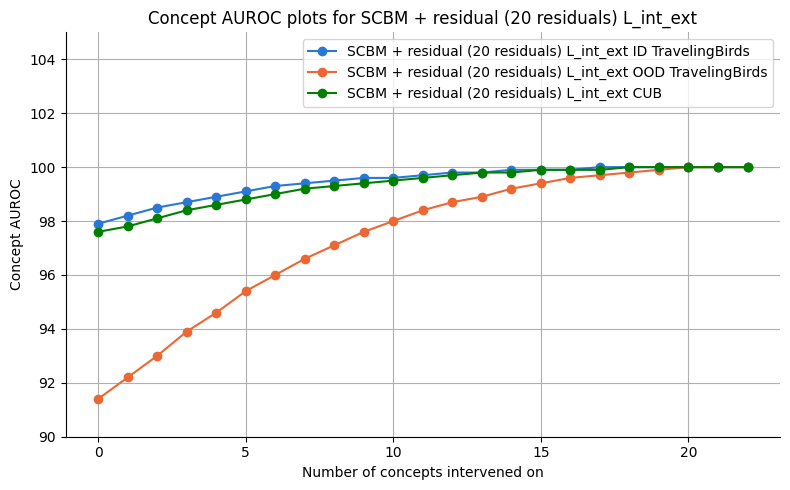

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Concept AUROC plots for SCBM + residual (20 residuals) L_int_ext'}, xlabel='Number of concepts intervened on', ylabel='Concept AUROC'>)

In [57]:

models = [
    ("SCBM + residual (20 residuals) L_int_ext ID TravelingBirds", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual", "TravelingBirds", "test_bg_train"),
    ("SCBM + residual (20 residuals) L_int_ext OOD TravelingBirds", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual", "TravelingBirds", "test_bg_test"),
    ("SCBM + residual (20 residuals) L_int_ext CUB", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5", "scbm_residual", "CUB")
]   



colors = ["#2a78d6", "#eb6834", "green"]

    
plot_concept_auroc(models, colors, "Concept AUROC plots for SCBM + residual (20 residuals) L_int_ext")





## Complete OOD TravelingBirds experiment

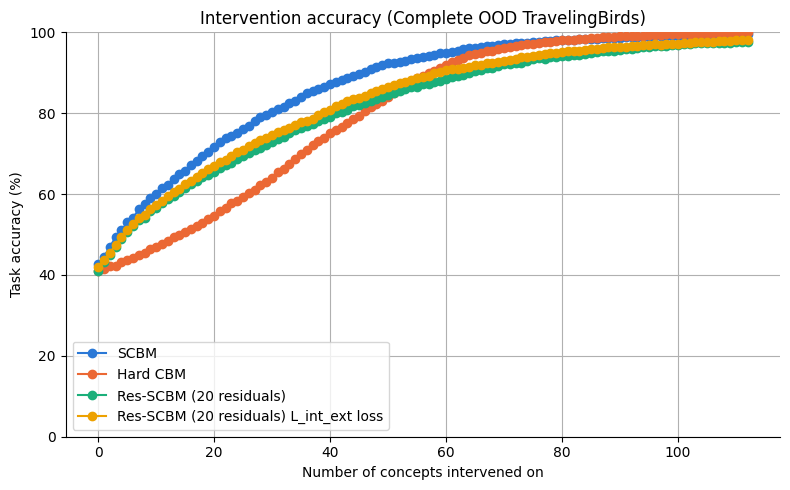

In [40]:
models = [("SCBM", "class_attr_data_10_2026-08-11_18-05-59_ffac3", "scbm"),
          ("Hard CBM", "class_attr_data_10_2026-08-11_18-16-11_ea7f3", "cbm"),
          ("Res-SCBM (20 residuals)", "class_attr_data_10_fixed_residuals_20_2026-08-11_18-05-50_09e4d", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "class_attr_data_10_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_18-05-46_b0199", "scbm_residual"),
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]


plot(models, colors, "Intervention accuracy (Complete OOD TravelingBirds)")